## Trying PCA

## Trying to interpolate target to keep monthly features

In [1]:
from data_ingestion import *
from preprocessing_engineering_selection import *

# Get merged dataframe with all variables
merged_data_df = get_and_merge_all_data()

filtered_df = merged_data_df[(merged_data_df['date'] > '1970-01-01') & (merged_data_df['date'] < '2025-01-01')]

filtered_df = filtered_df.rename(columns={
    'Privately owned apartments - Asking price': 'appartments_asking_price',
    'Privately owned apartments - Transaction price': 'appartments_transaction_price',
    'Single-family houses - Asking price': 'houses_asking_price',
    'Single-family houses - Transaction price': 'houses_transaction_price',
    'Rents - Industrial and commercial space ': 'rents_industrial_commercial',
    'Rents - Office space ': 'rents_office', 
    'Rents - Rental housing units ': 'rents_houses',
    'Rents - Retail space ': 'rents_retail',
    'Acquisition of Swiss citizenship': 'acquisition_ch_citizenship',
    'Natural Change': 'pop_natural_change',
    'Net migration': 'ch_net_migration',
    'Switzerland - CHF - Call money rate (Tomorrow next) - 1 day': 'average_call_money_rate',
    'Origination - Relevant foreign currency positions': 'money_origin_foreign_currency_position',
    'Origination - Securities portfolio': 'money_origin_securities_portfolio',
    'Origination - Money market transactions': 'money_origin_money_market_transactions',
    'Origination - Other': 'money_origin_other',
    'Origination - Monetary base': 'money_origin_monetary_base',
    'Utilisation - Banknotes in circulation': 'banknotes_in_circulation',
    'Utilisation - Sight deposit accounts of domestic banks': 'sight_deposits_banks',
    'Level - Currency in circulation': 'currency_in_circulation',
    'Level - Deposits in transaction accounts': 'deposits_in_transaction_accounts',
    'Level - Monetary aggregate M3': 'M3_supply',
    'Banks in Switzerland - Total domestic and foreign - Total loans - Utilisation': 'swiss_banks_total_loans',
    'Banks in Switzerland - Total domestic and foreign - Mortgage loans - Utilisation': 'swiss_banks_mortgage_loans',
    'Value, in CHF millions - Gross domestic product': 'gpd',
    'SFSO - Inflation according to the national consumer price index': 'inflation'
})

df_eng = engineer_features(filtered_df)

target_cols = [col for col in [
        'appartments_asking_price',
        'appartments_transaction_price',
        'houses_asking_price',
        'houses_transaction_price'
    ] if col in df_eng.columns]  # Only include targets that exist in df

exclude_cols = [col for col in [
    'date', 
    'appartments_asking_price_ma3', 
    'appartments_transaction_price_ma3',	
    'houses_asking_price_ma3',	
    'houses_transaction_price_ma3',	
    'appartments_asking_growth',	
    'appartments_transaction_growth',	
    'houses_asking_growth',
    'houses_transaction_growth',
    'appartments_ask_to_trans_ratio',
    'houses_ask_to_trans_ratio',
    'rate_x_mortgage'] if col in df_eng.columns]

lagged_df = generate_lagged_features(df=df_eng, target_cols=target_cols, exclude_cols=exclude_cols)
only_lagged_df = drop_non_lagged_features(df=lagged_df, target_cols=target_cols, exclude_cols=exclude_cols)

target_cols = [col for col in [
        'appartments_asking_price',
        'appartments_transaction_price',
        'houses_asking_price',
        'houses_transaction_price'
    ] if col in only_lagged_df.columns]  # Only include targets that exist in df

preprocessed_df = preprocess_df(only_lagged_df, target_cols=target_cols)

preprocessed_df = preprocessed_df.ffill()

model_df = preprocessed_df.drop(columns={        
    'appartments_asking_price',
    'appartments_transaction_price',
    'houses_transaction_price'})

c:\Users\TylerKleinbauer\Dropbox\Tyler\Endeavors\Portfolio\predicting_housing_market_prices\preprocessing_engineering_selection.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_lagged[f'{col}_lag{lag}'] = df_lagged[col].shift(lag)
c:\Users\TylerKleinbauer\Dropbox\Tyler\Endeavors\Portfolio\predicting_housing_market_prices\preprocessing_engineering_selection.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_lagged[f'{col}_lag{lag}'] = df_lagged[col].shift(lag)
c:\Users\TylerKleinbauer\Dropbox\Tyler\Endeavors\Portfol

Best model: Lasso
Best params: {'model': Lasso(max_iter=50000), 'model__alpha': 0.01, 'pca__n_components': 9}
Test MSE: 173.45
Test R²: -0.32
Number of components: 9
Explained variance ratio: 0.942


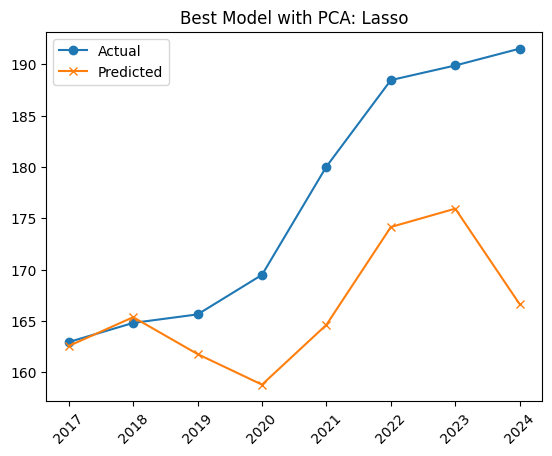


PCA Loadings for All 9 Components:

Top loadings for PC1:
                                                         PC1
M3_supply_lag1                                      0.106165
M3_supply_lag2                                      0.105969
banknotes_in_circulation_lag2                       0.105757
banknotes_in_circulation_lag1                       0.105634
Level - Monetary aggregate M2_lag1                  0.105426
Banks in Switzerland - Domestic - Mortgage loan...  0.105370
swiss_banks_mortgage_loans_lag2                     0.105331
Level - Monetary aggregate M1_lag1                  0.105315
deposits_in_transaction_accounts_lag1               0.105296
swiss_banks_mortgage_loans_lag1                     0.105225

Top loadings for PC2:
                                                  PC2
pop_natural_change_lag1                      0.198004
Live births_lag1                             0.194582
rents_retail_lag2                            0.194119
pop_natural_change_lag2        

In [2]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Data (assuming model_df has all 67 features initially)
X = model_df.drop(columns=['houses_asking_price', 'date'])  # Full feature set, e.g., 67 features
y = model_df['houses_asking_price']
train_size = int(0.8 * len(model_df))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Pipeline with PCA and placeholder for model
pipeline = Pipeline([
    ('scaler', StandardScaler()),           # Scale features first
    ('pca', PCA()),                         # PCA to reduce dimensionality
    ('model', Lasso())                      # Placeholder for model
])

# Parameter grid with PCA components and model hyperparameters
param_grid = [
    # Lasso with PCA
    {
        'pca__n_components': [1,2,3,4,5,6,7,8,9, 10],  # Number of principal components
        'model': [Lasso(max_iter=50000)],
        'model__alpha': [0.01, 0.1, 1.0, 10.0]
    },
    # Ridge with PCA
    {
        'pca__n_components': [1,2,3,4,5,6,7,8,9, 10],
        'model': [Ridge()],
        'model__alpha': [0.1, 1.0, 10.0, 50.0]
    },
    # ElasticNet with PCA
    {
        'pca__n_components': [1,2,3,4,5,6,7,8,9, 10],
        'model': [ElasticNet(max_iter=50000)],
        'model__alpha': [0.1, 0.5, 1.0, 2.0],
        'model__l1_ratio': [0.1, 0.5, 0.9]  # Reduced to avoid over-searching
    },
    # Random Forest with PCA
    {
        'pca__n_components': [1,2,3,4,5,6,7,8,9, 10],
        'model': [RandomForestRegressor(random_state=42)],
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5, 7],
        'model__min_samples_split': [2, 5]
    },
    # Gradient Boosting with PCA
    {
        'pca__n_components': [1,2,3,4,5,6,7,8,9, 10],
        'model': [HistGradientBoostingRegressor(random_state=42)],
        'model__max_iter': [100, 200],
        'model__max_depth': [3, 5]
    }
]

# Grid search with time series CV
tscv = TimeSeriesSplit(n_splits=2)
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1  # Use all CPU cores for speed
)
grid_search.fit(X_train, y_train)

# Results
best_model = grid_search.best_estimator_['model']
best_pca = grid_search.best_estimator_['pca']
print(f"Best model: {best_model.__class__.__name__}")
print(f"Best params: {grid_search.best_params_}")
y_pred = grid_search.predict(X_test)
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Test R²: {r2_score(y_test, y_pred):.2f}")
print(f"Number of components: {best_pca.n_components_}")
print(f"Explained variance ratio: {sum(best_pca.explained_variance_ratio_):.3f}")

# Plot predictions
plt.plot(model_df['date'].iloc[train_size:], y_test, label='Actual', marker='o')
plt.plot(model_df['date'].iloc[train_size:], y_pred, label='Predicted', marker='x')
plt.legend()
plt.xticks(rotation=45)
plt.title(f"Best Model with PCA: {best_model.__class__.__name__}")
plt.show()

# Get the number of components from the best model
n_components = grid_search.best_params_['pca__n_components']

# Inspect PCA components (loadings for the best number of PCs)
print(f"\nPCA Loadings for All {n_components} Components:")
loadings = pd.DataFrame(
    grid_search.best_estimator_['pca'].components_.T,  # Use the fitted PCA from best_estimator_
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]  # Use the actual number of components
)

# Show top 10 features by absolute value for each PC
for pc in loadings.columns:
    print(f"\nTop loadings for {pc}:")
    print(loadings[[pc]].sort_values(by=pc, key=abs, ascending=False).head(10))

c:\Users\TylerKleinbauer\anaconda3\envs\LangGraphTutorial\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\TylerKleinbauer\anaconda3\envs\LangGraphTutorial\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\TylerKleinbauer\anaconda3\envs\LangGraphTutorial\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.544e+02, tolerance: 2.028e-01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the 

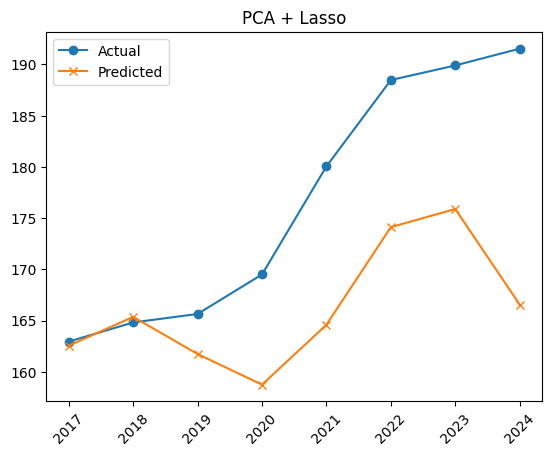

Test MSE: 174.66
Test R²: -0.33
Explained variance ratio: 0.943

PCA Loadings for All 9 Components:

Top loadings for PC1:
                                                         PC1
M3_supply_lag1                                      0.105671
M3_supply_lag2                                      0.105480
banknotes_in_circulation_lag2                       0.105200
banknotes_in_circulation_lag1                       0.105074
Banks in Switzerland - Domestic - Mortgage loan...  0.104904
Level - Monetary aggregate M2_lag1                  0.104900
swiss_banks_mortgage_loans_lag2                     0.104867
deposits_in_transaction_accounts_lag1               0.104811
Level - Monetary aggregate M1_lag1                  0.104782
swiss_banks_mortgage_loans_lag1                     0.104761

Top loadings for PC2:
                                                  PC2
pop_natural_change_lag1                      0.197654
Live births_lag1                             0.194358
rents_retail_lag2    

In [12]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Data (full 170 features)
X = model_df.drop(columns=['houses_asking_price'])  # 170 features
X['years_since_1985'] = model_df['date'] - 1985    # Add trend
X = X.drop(columns=['date'])
y = model_df['houses_asking_price']
train_size = int(0.8 * len(model_df))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Pipeline with PCA and Lasso
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),  # Fixed at 5 from your best
    ('model', Lasso())
])

param_grid = {
    'pca__n_components': [1,2,3,4,5,6,7,8,9,10],  # Number of principal components
    'model': [Lasso(max_iter=50000)],
    'model__alpha': list(np.arange(0, 10, 0.1).round(1))
    }

tscv = TimeSeriesSplit(n_splits=2)

grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=tscv, 
    scoring='neg_mean_squared_error'
)

grid_search.fit(X_train, y_train)
best_pca = grid_search.best_estimator_['pca']
y_pred = grid_search.predict(X_test)

# Plot
plt.plot(model_df['date'].iloc[train_size:], y_test, label='Actual', marker='o')
plt.plot(model_df['date'].iloc[train_size:], y_pred, label='Predicted', marker='x')
plt.legend()
plt.xticks(rotation=45)
plt.title("PCA + Lasso")
plt.show()

# Results
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Test R²: {r2_score(y_test, y_pred):.2f}")
print(f"Explained variance ratio: {sum(best_pca.explained_variance_ratio_):.3f}")

# Inspect PCA components (loadings for the best number of PCs)
print(f"\nPCA Loadings for All {n_components} Components:")
loadings = pd.DataFrame(
    grid_search.best_estimator_['pca'].components_.T,  # Use the fitted PCA from best_estimator_
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]  # Use the actual number of components
)

# Show top 10 features by absolute value for each PC
for pc in loadings.columns:
    print(f"\nTop loadings for {pc}:")
    print(loadings[[pc]].sort_values(by=pc, key=abs, ascending=False).head(10))

## Trying to interpolate target to keep monthly features

Best model: ElasticNet
Best params: {'model': ElasticNet(), 'model__alpha': 1.0, 'model__l1_ratio': 0.9}
Test MSE: 164.72
Test R²: -2.84
Selected features: ['money_origin_money_market_transactions', 'appartments_asking_price_lag12', 'appartments_asking_price_lag24', 'appartments_asking_price_ma12', 'appartments_transaction_price_lag12', 'appartments_transaction_price_lag24', 'appartments_transaction_price_ma12', 'houses_transaction_price_lag12', 'houses_transaction_price_lag24', 'houses_transaction_price_ma12', 'appartments_asking_growth_lag12', 'appartments_ask_to_trans_ratio_lag12', 'rate_x_mortgage_lag12', 'rents_industrial_commercial_lag12', 'rents_industrial_commercial_lag24', 'rents_office_lag12', 'rents_office_lag24', 'rents_houses_lag12', 'rents_houses_lag24', 'rents_retail_lag12', 'rents_retail_lag24', 'acquisition_ch_citizenship_lag12', 'acquisition_ch_citizenship_lag24', 'pop_natural_change_lag12', 'pop_natural_change_lag24', 'ch_net_migration_lag12', 'ch_net_migration_lag24

c:\Users\TylerKleinbauer\anaconda3\envs\LangGraphTutorial\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.944e+01, tolerance: 1.752e+01
  model = cd_fast.enet_coordinate_descent(


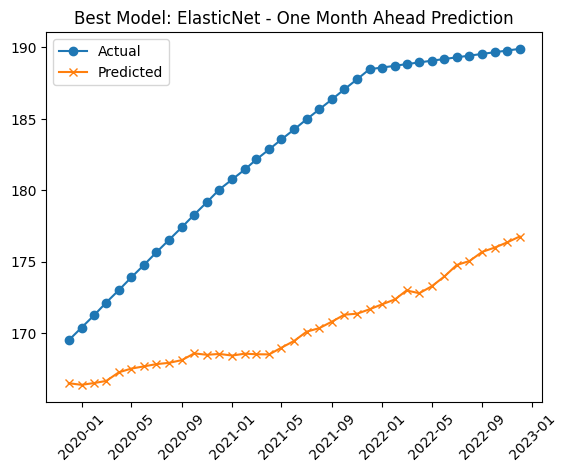

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Assuming data_ingestion.py provides these functions
from data_ingestion import *

# Data loading function (unchanged)
def get_and_merge_all_data_monthly():
    dfs = get_clean_housing_data()
    housing_df = dfs['housing_df']
    housing_df['date'] = pd.to_datetime(housing_df['date']).dt.to_period('M').dt.to_timestamp()
    housing_df = housing_df.set_index('date').resample('MS').interpolate().reset_index()
    
    raw_demographics_df = get_demographics_data()
    demographics_df = long_to_wide_demographics(raw_demographics_df)
    demographics_df['date'] = pd.to_datetime(demographics_df['date']).dt.to_period('M').dt.to_timestamp()
    demographics_df = demographics_df.set_index('date').resample('MS').interpolate().reset_index()
    
    monthly_interest_rates_df = get_and_process_snb_data("https://data.snb.ch/api/cube/zimoma/data/json/en")
    monthly_interest_rates_df['date'] = pd.to_datetime(monthly_interest_rates_df['date']).dt.to_period('M').dt.to_timestamp()
    
    monthly_monetary_base_df = get_and_process_snb_data("https://data.snb.ch/api/cube/snbmoba/data/json/en")
    monthly_monetary_base_df['date'] = pd.to_datetime(monthly_monetary_base_df['date']).dt.to_period('M').dt.to_timestamp()
    
    monthly_monetary_aggregate_df = get_and_process_snb_data_two_header_levels("https://data.snb.ch/api/cube/snbmonagg/data/json/en")
    monthly_monetary_aggregate_df['date'] = pd.to_datetime(monthly_monetary_aggregate_df['date']).dt.to_period('M').dt.to_timestamp()
    
    monthly_mortgage_df = get_and_process_mortgage_data("https://data.snb.ch/api/cube/bakredinausbm/data/json/en")
    monthly_mortgage_df['date'] = pd.to_datetime(monthly_mortgage_df['date']).dt.to_period('M').dt.to_timestamp()
    
    q_gdp_df = get_and_process_snb_data_two_header_levels("https://data.snb.ch/api/cube/gdpgnp/data/json/en")
    q_gdp_df = q_gdp_df[['date', 'Value, in CHF millions - Gross domestic product']]
    q_gdp_df['date'] = pd.to_datetime(q_gdp_df['date']).dt.to_period('M').dt.to_timestamp()
    q_gdp_df = q_gdp_df.set_index('date').resample('MS').interpolate().reset_index()
    q_gdp_df = q_gdp_df[q_gdp_df['date'].dt.year != 2024]
    
    population_df = get_swiss_population_data()
    population_df['date'] = pd.to_datetime(population_df['date']).dt.to_period('M').dt.to_timestamp()
    population_df = population_df.set_index('date').resample('MS').interpolate().reset_index()
    
    monthly_inflation_df = get_and_process_snb_data("https://data.snb.ch/api/cube/plkoprinfla/data/json/en")
    monthly_inflation_df = monthly_inflation_df[['date', 'SFSO - Inflation according to the national consumer price index']]
    monthly_inflation_df['date'] = pd.to_datetime(monthly_inflation_df['date']).dt.to_period('M').dt.to_timestamp()
    
    merged_df = housing_df.copy()
    for df in [demographics_df, monthly_interest_rates_df, monthly_monetary_base_df, monthly_monetary_aggregate_df,
               monthly_mortgage_df, q_gdp_df, population_df, monthly_inflation_df]:
        merged_df = merged_df.merge(df, on='date', how='inner')
    
    merged_df = filter_df(merged_df)
    merged_df['year_month'] = merged_df['date'].dt.to_period('M')
    merged_df = merged_df.groupby('year_month').mean(numeric_only=True).reset_index()
    merged_df['date'] = merged_df['year_month'].dt.to_timestamp()
    merged_df = merged_df.drop(columns=['year_month'])
    
    return merged_df

# Adjusted feature engineering with yearly lags
def engineer_features(df, ma_window=12):
    df_eng = df.copy()
    price_cols = ['appartments_asking_price', 'appartments_transaction_price', 'houses_transaction_price']
    # Exclude houses_asking_price from features to prevent leakage
    for col in price_cols:
        if col in df_eng.columns:
            df_eng[f'{col}_lag12'] = df_eng[col].shift(12)  # 1-year lag
            df_eng[f'{col}_lag24'] = df_eng[col].shift(24)  # 2-year lag
            df_eng[f'{col}_ma12'] = df_eng[col].shift(1).rolling(window=12, min_periods=12).mean()  # Past 12 months avg
    
    # Growth and ratios using lagged values
    for prop in ['appartments']:
        df_eng[f'{prop}_asking_growth_lag12'] = (
            (df_eng[f'{prop}_asking_price_lag12'] - df_eng[f'{prop}_asking_price_lag24']) / 
            df_eng[f'{prop}_asking_price_lag24']
        )
        df_eng[f'{prop}_ask_to_trans_ratio_lag12'] = (
            df_eng[f'{prop}_asking_price_lag12'] / df_eng[f'{prop}_transaction_price_lag12']
        )
    
    df_eng['rate_x_mortgage_lag12'] = (
        df_eng['average_call_money_rate'].shift(12) * df_eng['swiss_banks_mortgage_loans'].shift(12)
    )
    return df_eng

def generate_yearly_lagged_features(df, max_lag_years=2, exclude_cols=['date'], target_cols=['houses_asking_price']):
    df_lagged = df.copy()
    feature_cols = [col for col in df.columns if col not in exclude_cols + target_cols]
    for col in feature_cols:
        for lag in [12, 24]:  # 1 and 2 years
            df_lagged[f'{col}_lag{lag}'] = df_lagged[col].shift(lag)
    # Add target lags as features
    for lag in [12, 24]:
        df_lagged[f'houses_asking_price_lag{lag}'] = df_lagged['houses_asking_price'].shift(lag)
    return df_lagged

def drop_non_lagged_features(df, target_cols=['houses_asking_price'], exclude_cols=['date']):
    cols_to_keep = [col for col in exclude_cols if col in df.columns] + \
                   [col for col in target_cols if col in df.columns] + \
                   [col for col in df.columns if 'lag' in col or 'ma' in col]
    return df[cols_to_keep]

# Load and prepare data
model_df = get_and_merge_all_data_monthly()
model_df = model_df[model_df['date'] <= '2023-12-31']

# Shift target for one-month-ahead prediction
model_df['target_houses_asking_price'] = model_df['houses_asking_price'].shift(-1)

# Engineer features
model_df_eng = engineer_features(model_df)
model_df_lagged = generate_yearly_lagged_features(model_df_eng)
model_df_final = drop_non_lagged_features(model_df_lagged, target_cols=['target_houses_asking_price'])

# After feature engineering, before splitting:
# Drop NaN values and align X and y
X = model_df_final.drop(columns=['target_houses_asking_price', 'date'])
X['month'] = model_df_final['date'].dt.month
y = model_df_final['target_houses_asking_price']
dates = model_df_final['date']

# Drop NaN values from all series at once
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]
y = y[mask]
dates = dates[mask]

# Now split the clean data
train_size = X[X.index < model_df_final[model_df_final['date'] < '2020-01-01'].index[-1]].shape[0]
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
dates_train, dates_test = dates.iloc[:train_size], dates.iloc[train_size:]

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso())
])

# Parameter grid
param_grid = [
    {'model': [Lasso(max_iter=50000)], 'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    {'model': [Ridge()], 'model__alpha': [0.1, 1.0, 10.0, 50.0]},
    {'model': [ElasticNet()], 'model__alpha': [0.1, 0.5, 1.0], 'model__l1_ratio': [0.1, 0.5, 0.9]},
    {'model': [RandomForestRegressor(random_state=42)], 'model__n_estimators': [100, 200], 'model__max_depth': [3, 5, 7]},
    {'model': [HistGradientBoostingRegressor(random_state=42)], 'model__max_iter': [100, 200], 'model__max_depth': [3, 5]}
]

# Grid search
tscv = TimeSeriesSplit(n_splits=2)
grid_search = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Results
best_model = grid_search.best_estimator_['model']
print(f"Best model: {best_model.__class__.__name__}")
print(f"Best params: {grid_search.best_params_}")
y_pred = grid_search.predict(X_test)
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Test R²: {r2_score(y_test, y_pred):.2f}")

# Feature importance
if isinstance(best_model, (Lasso, Ridge, ElasticNet)):
    coefs = best_model.coef_
    selected_features = X.columns[coefs != 0].tolist() if isinstance(best_model, Lasso) else X.columns.tolist()
    print(f"Selected features: {selected_features}")
else:
    importances = best_model.feature_importances_
    print(f"Feature importances: {dict(zip(X.columns, importances))}")

# Plot
plt.plot(dates_test, y_test, label='Actual', marker='o')
plt.plot(dates_test, y_pred, label='Predicted', marker='x')
plt.legend()
plt.xticks(rotation=45)
plt.title(f"Best Model: {best_model.__class__.__name__} - One Month Ahead Prediction")
plt.show()

Best model: Lasso
Best params: {'model': Lasso(max_iter=50000), 'model__alpha': 1.0}
Test MSE: 71.23
Test R²: -5.16
Selected features: ['money_origin_other_lag12', 'swiss_banks_total_loans_lag24', 'gpd_lag12', 'gpd_lag24', 'target_houses_asking_price_lag12']


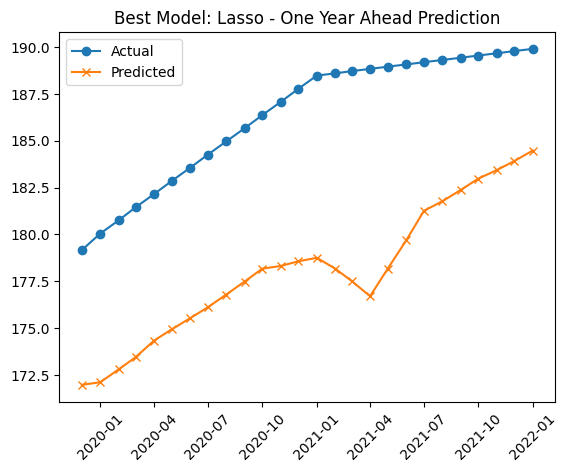

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Assuming data_ingestion.py provides these functions
from data_ingestion import *

# Data loading function (unchanged)
def get_and_merge_all_data_monthly():
    dfs = get_clean_housing_data()
    housing_df = dfs['housing_df']
    housing_df['date'] = pd.to_datetime(housing_df['date']).dt.to_period('M').dt.to_timestamp()
    housing_df = housing_df.set_index('date').resample('MS').interpolate().reset_index()
    
    raw_demographics_df = get_demographics_data()
    demographics_df = long_to_wide_demographics(raw_demographics_df)
    demographics_df['date'] = pd.to_datetime(demographics_df['date']).dt.to_period('M').dt.to_timestamp()
    demographics_df = demographics_df.set_index('date').resample('MS').interpolate().reset_index()
    
    monthly_interest_rates_df = get_and_process_snb_data("https://data.snb.ch/api/cube/zimoma/data/json/en")
    monthly_interest_rates_df['date'] = pd.to_datetime(monthly_interest_rates_df['date']).dt.to_period('M').dt.to_timestamp()
    
    monthly_monetary_base_df = get_and_process_snb_data("https://data.snb.ch/api/cube/snbmoba/data/json/en")
    monthly_monetary_base_df['date'] = pd.to_datetime(monthly_monetary_base_df['date']).dt.to_period('M').dt.to_timestamp()
    
    monthly_monetary_aggregate_df = get_and_process_snb_data_two_header_levels("https://data.snb.ch/api/cube/snbmonagg/data/json/en")
    monthly_monetary_aggregate_df['date'] = pd.to_datetime(monthly_monetary_aggregate_df['date']).dt.to_period('M').dt.to_timestamp()
    
    monthly_mortgage_df = get_and_process_mortgage_data("https://data.snb.ch/api/cube/bakredinausbm/data/json/en")
    monthly_mortgage_df['date'] = pd.to_datetime(monthly_mortgage_df['date']).dt.to_period('M').dt.to_timestamp()
    
    q_gdp_df = get_and_process_snb_data_two_header_levels("https://data.snb.ch/api/cube/gdpgnp/data/json/en")
    q_gdp_df = q_gdp_df[['date', 'Value, in CHF millions - Gross domestic product']]
    q_gdp_df['date'] = pd.to_datetime(q_gdp_df['date']).dt.to_period('M').dt.to_timestamp()
    q_gdp_df = q_gdp_df.set_index('date').resample('MS').interpolate().reset_index()
    q_gdp_df = q_gdp_df[q_gdp_df['date'].dt.year != 2024]
    
    population_df = get_swiss_population_data()
    population_df['date'] = pd.to_datetime(population_df['date']).dt.to_period('M').dt.to_timestamp()
    population_df = population_df.set_index('date').resample('MS').interpolate().reset_index()
    
    monthly_inflation_df = get_and_process_snb_data("https://data.snb.ch/api/cube/plkoprinfla/data/json/en")
    monthly_inflation_df = monthly_inflation_df[['date', 'SFSO - Inflation according to the national consumer price index']]
    monthly_inflation_df['date'] = pd.to_datetime(monthly_inflation_df['date']).dt.to_period('M').dt.to_timestamp()
    
    merged_df = housing_df.copy()
    for df in [demographics_df, monthly_interest_rates_df, monthly_monetary_base_df, monthly_monetary_aggregate_df,
               monthly_mortgage_df, q_gdp_df, population_df, monthly_inflation_df]:
        merged_df = merged_df.merge(df, on='date', how='inner')
    
    merged_df = filter_df(merged_df)
    merged_df['year_month'] = merged_df['date'].dt.to_period('M')
    merged_df = merged_df.groupby('year_month').mean(numeric_only=True).reset_index()
    merged_df['date'] = merged_df['year_month'].dt.to_timestamp()
    merged_df = merged_df.drop(columns=['year_month'])
    
    return merged_df

# Adjusted feature engineering with yearly lags
def engineer_features(df, ma_window=12):
    df_eng = df.copy()
    price_cols = ['appartments_asking_price', 'appartments_transaction_price', 'houses_transaction_price']
    # Exclude houses_asking_price from features to prevent leakage
    for col in price_cols:
        if col in df_eng.columns:
            df_eng[f'{col}_lag12'] = df_eng[col].shift(12)  # 1-year lag
            df_eng[f'{col}_lag24'] = df_eng[col].shift(24)  # 2-year lag
            df_eng[f'{col}_ma12'] = df_eng[col].shift(12).rolling(window=12, min_periods=12).mean()  # Past 12 months avg
    
    # Growth and ratios using lagged values
    for prop in ['appartments']:
        df_eng[f'{prop}_asking_growth_lag12'] = (
            (df_eng[f'{prop}_asking_price_lag12'] - df_eng[f'{prop}_asking_price_lag24']) / 
            df_eng[f'{prop}_asking_price_lag24']
        )
        df_eng[f'{prop}_ask_to_trans_ratio_lag12'] = (
            df_eng[f'{prop}_asking_price_lag12'] / df_eng[f'{prop}_transaction_price_lag12']
        )
    
    df_eng['rate_x_mortgage_lag12'] = (
        df_eng['average_call_money_rate'].shift(12) * df_eng['swiss_banks_mortgage_loans'].shift(12)
    )
    return df_eng

def generate_yearly_lagged_features(df, max_lag_years=2, exclude_cols=['date'], target_cols=['houses_asking_price']):
    df_lagged = df.copy()
    feature_cols = [col for col in df.columns if col not in exclude_cols + target_cols]
    for col in feature_cols:
        for lag in [12, 24]:  # 1 and 2 years
            df_lagged[f'{col}_lag{lag}'] = df_lagged[col].shift(lag)
    # Add target lags as features
    for lag in [12, 24]:
        df_lagged[f'houses_asking_price_lag{lag}'] = df_lagged['houses_asking_price'].shift(lag)
    return df_lagged

def drop_non_lagged_features(df, target_cols=['houses_asking_price'], exclude_cols=['date']):
    # Only keep features that are at least 12 months old
    cols_to_keep = []
    for col in df.columns:
        # Check if it's in exclude_cols or target_cols first
        if col in exclude_cols or col in target_cols:
            cols_to_keep.append(col)
        # Check for lag columns
        elif 'lag' in col:
            try:
                # Extract the number after 'lag'
                lag_value = int(''.join(filter(str.isdigit, col)))
                if lag_value >= 12:
                    cols_to_keep.append(col)
            except ValueError:
                # If we can't parse the lag value, skip this column
                continue
    
    return df[cols_to_keep]

# Load and prepare data
model_df = get_and_merge_all_data_monthly()
model_df = model_df[model_df['date'] <= '2023-12-31']

# Shift target for one-year-ahead prediction
model_df['target_houses_asking_price'] = model_df['houses_asking_price'].shift(-12)

# Engineer features
model_df_eng = engineer_features(model_df)
model_df_lagged = generate_yearly_lagged_features(model_df_eng)
model_df_final = drop_non_lagged_features(model_df_lagged, target_cols=['target_houses_asking_price'])

# After feature engineering, before splitting:
# Drop NaN values and align X and y
X = model_df_final.drop(columns=['target_houses_asking_price', 'date'])
X['month'] = model_df_final['date'].dt.month
y = model_df_final['target_houses_asking_price']
dates = model_df_final['date']

# Drop NaN values from all series at once
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]
y = y[mask]
dates = dates[mask]

# Now split the clean data
# Ensure train/test split is on year boundaries
train_cutoff = '2020-01-01'  # This ensures we don't use partial years
train_size = X[X.index < model_df_final[model_df_final['date'] < train_cutoff].index[-1]].shape[0]
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
dates_train, dates_test = dates.iloc[:train_size], dates.iloc[train_size:]

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso())
])

# Parameter grid
param_grid = [
    {'model': [Lasso(max_iter=50000)], 'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    {'model': [Ridge()], 'model__alpha': [0.1, 1.0, 10.0, 50.0]},
    {'model': [ElasticNet()], 'model__alpha': [0.1, 0.5, 1.0], 'model__l1_ratio': [0.1, 0.5, 0.9]},
    {'model': [RandomForestRegressor(random_state=42)], 'model__n_estimators': [100, 200], 'model__max_depth': [3, 5, 7]},
    {'model': [HistGradientBoostingRegressor(random_state=42)], 'model__max_iter': [100, 200], 'model__max_depth': [3, 5]}
]

# Grid search
tscv = TimeSeriesSplit(n_splits=2)
grid_search = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Results
best_model = grid_search.best_estimator_['model']
print(f"Best model: {best_model.__class__.__name__}")
print(f"Best params: {grid_search.best_params_}")
y_pred = grid_search.predict(X_test)
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Test R²: {r2_score(y_test, y_pred):.2f}")

# Feature importance
if isinstance(best_model, (Lasso, Ridge, ElasticNet)):
    coefs = best_model.coef_
    selected_features = X.columns[coefs != 0].tolist() if isinstance(best_model, Lasso) else X.columns.tolist()
    print(f"Selected features: {selected_features}")
else:
    importances = best_model.feature_importances_
    print(f"Feature importances: {dict(zip(X.columns, importances))}")

# Plot
plt.plot(dates_test, y_test, label='Actual', marker='o')
plt.plot(dates_test, y_pred, label='Predicted', marker='x')
plt.legend()
plt.xticks(rotation=45)
plt.title(f"Best Model: {best_model.__class__.__name__} - One Year Ahead Prediction")
plt.show()